# Clase 5 · Probabilidad e inferencia: ¿real o azar?

**Módulo 1: Introducción y fundamentos estadísticos** · Diplomado en Ciencia de Datos Aplicada · UTFSM

Objetivos de la sesión: entender una muestra como una de muchas posibles; medir cuánto se mueve un resultado de una muestra a otra (la distribución muestral y el error estándar); construir intervalos de confianza; y responder con una prueba de hipótesis la pregunta que dejamos abierta en las clases 3 y 4: ¿la pendiente de −4,8 es real o es azar de 45 comunas?

**La pregunta de la clase:** ¿cuánto se movería este número con otra muestra?

## 1. Preparación

Hoy la EOD cumple un papel nuevo: trataremos sus 113 mil viajes **como si fueran la población completa** de viajes de Santiago. Es una ficción didáctica, pero permite hacer lo que en la realidad nunca se puede: tomar muchas muestras de la población y mirar cómo cambian los resultados entre una y otra. Por lo mismo, en esta parte no ponderamos: la población es la tabla tal cual.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import statsmodels.api as sm
# scipy.stats: las distribuciones de probabilidad con nombre
from scipy import stats

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = (
    "https://raw.githubusercontent.com/daniopitz/diplomado-cdd/"
    "main/datos/eod_stgo/"
)
# Si clonó el repositorio del curso, los datos ya están en su disco:
# BASE = "datos/eod_stgo/"

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)

# La población de hoy: la duración de cada viaje, sin faltantes ni ceros
duracion = viajes["TiempoViaje"].dropna()
duracion = duracion[duracion > 0]
len(duracion)

113113

## 2. Variables aleatorias y distribuciones

**Objetivo:** ponerle nombre a algo que ya usamos: la duración de un viaje es una **variable aleatoria**, y su histograma es su **distribución**.

Una variable aleatoria es una cantidad cuyo valor depende del azar: la duración del próximo viaje que registre la encuesta puede ser 10 minutos o 90, y no lo sabemos de antemano. Su **distribución** dice qué valores puede tomar y con qué frecuencia; para una población completa, es exactamente el histograma. Y la **esperanza** $E[X]$ es la media de esa distribución: el valor promedio que esperaríamos a la larga. La **varianza** mide cuánto se dispersa alrededor de la esperanza. Son los mismos resúmenes de la clase 2, ahora vistos como propiedades de la población y no de una muestra.

In [4]:
print("Esperanza (media poblacional):", round(duracion.mean(), 2), "min")
print("Mediana:", duracion.median(), "min")
print("Desviación estándar:", round(duracion.std(), 2), "min")
print("Asimetría:", round(duracion.skew(), 2))

Esperanza (media poblacional): 36.93 min
Mediana: 30.0 min
Desviación estándar: 36.05 min
Asimetría: 5.3


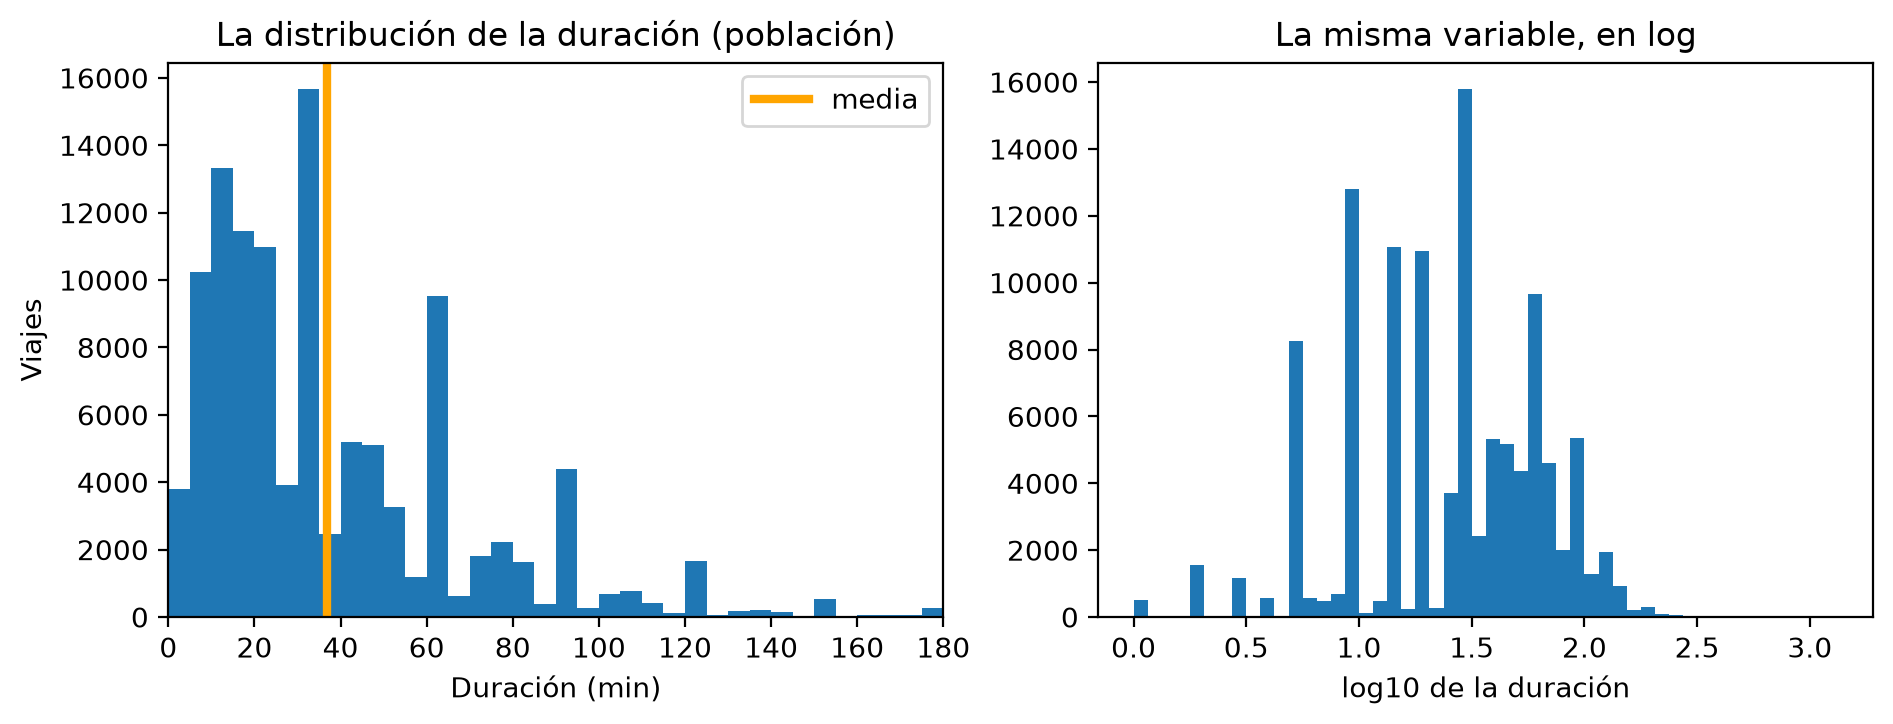

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(duracion, bins=range(0, 181, 5))
axes[0].axvline(duracion.mean(), color="orange", lw=3, label="media")
axes[0].set(xlim=(0, 180), xlabel="Duración (min)", ylabel="Viajes",
            title="La distribución de la duración (población)")
axes[0].legend()
axes[1].hist(np.log10(duracion), bins=50)
axes[1].set(xlabel="log10 de la duración", title="La misma variable, en log")
plt.show()

### Las distribuciones con nombre

Algunas formas aparecen tanto que tienen nombre y fórmula. La más importante es la **normal**, $X \sim N(\mu, \sigma^2)$: la campana simétrica, definida por dos parámetros, $\mu$ (el centro) y $\sigma$ (la dispersión). Su regla práctica: el 68% de los valores cae a menos de una $\sigma$ de la media, el 95% a menos de $1{,}96\,\sigma$ y el 99,7% a menos de $3\sigma$. Ese 1,96 va a reaparecer en los intervalos de confianza.

La duración en minutos no es normal (cola larga, asimetría 5,3), pero en log se parece bastante. Comparemos cada histograma con la normal que tiene su misma media y desviación:

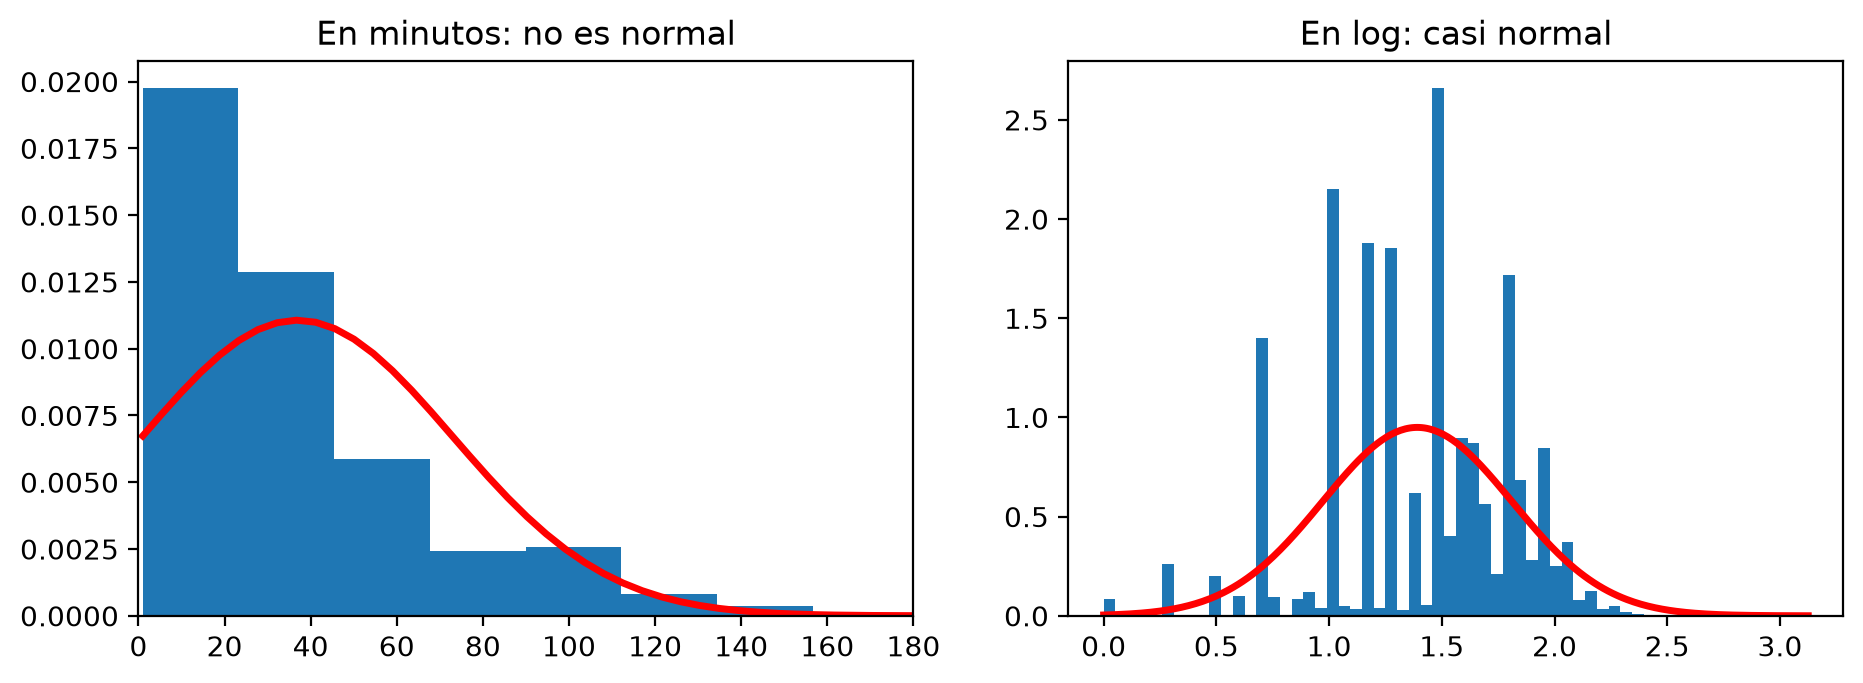

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, x, titulo in [(axes[0], duracion, "En minutos: no es normal"),
                      (axes[1], np.log10(duracion), "En log: casi normal")]:
    ax.hist(x, bins=60, density=True)
    grilla = np.linspace(x.min(), x.max(), 300)
    # stats.norm.pdf: la curva de la normal con esa media y esa sd
    ax.plot(grilla, stats.norm.pdf(grilla, x.mean(), x.std()), color="red", lw=2.5)
    ax.set_title(titulo)
axes[0].set_xlim(0, 180)
plt.show()

Esto explica dos cosas de la clase 4: por qué el log ayudó a la regresión (en log la variable se comporta como una normal) y por qué la normal aparece en todas partes: cuando muchas causas pequeñas se suman, el resultado tiende a ser normal. Eso último es un teorema, y lo veremos actuar en la próxima sección.

Otra distribución con nombre, para variables que cuentan: la **binomial**, el número de éxitos en $n$ intentos independientes con probabilidad $p$ cada uno. Si tomo 20 viajes al azar y cuento cuántos son en auto:

Fracción de viajes en auto: 0.233


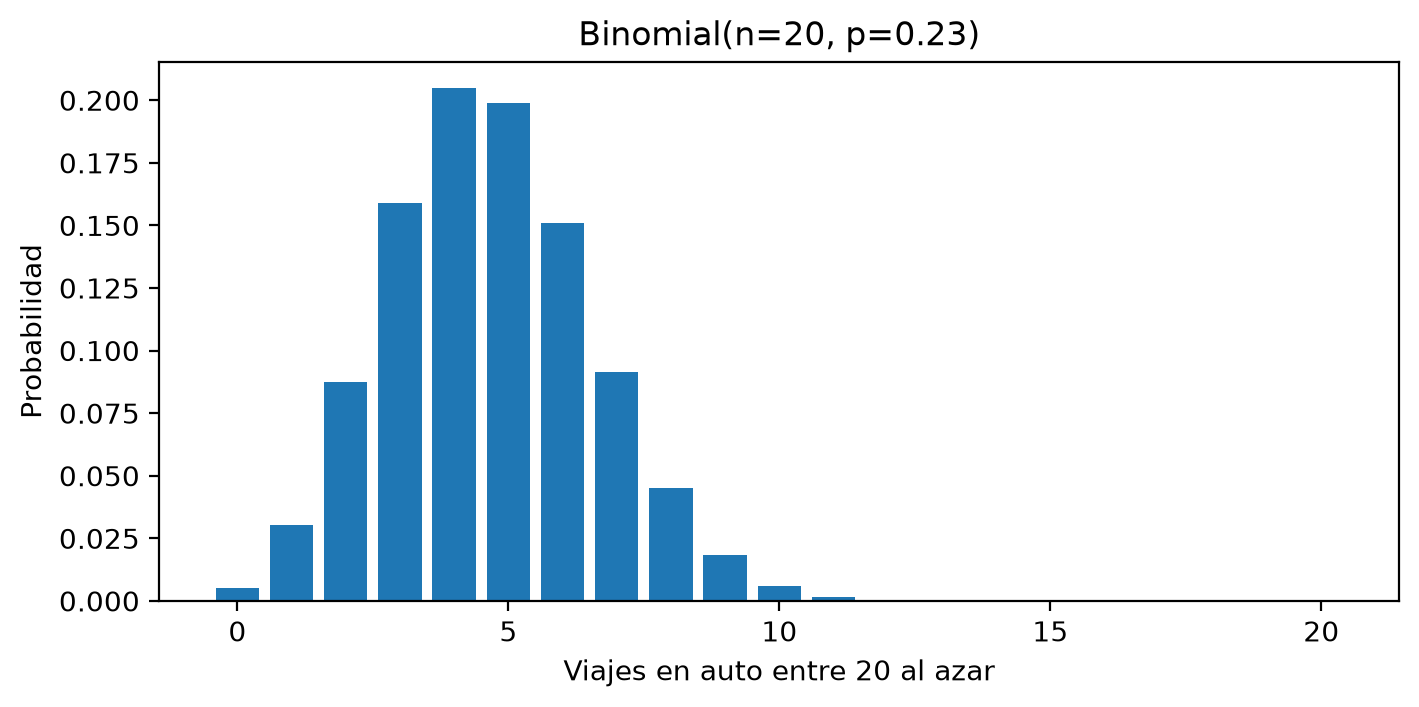

In [7]:
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})
viajes_modo = viajes.merge(modo_por_viaje, on="Viaje").merge(
    nombres_modo, left_on="ModoDifusion", right_on="ID")
p_auto = (viajes_modo["NombreModo"] == "Auto").mean()
print("Fracción de viajes en auto:", round(p_auto, 3))

k = np.arange(0, 21)
fig, ax = plt.subplots(figsize=(8, 3.5))
# stats.binom.pmf: la probabilidad de exactamente k éxitos
ax.bar(k, stats.binom.pmf(k, 20, p_auto))
ax.set(xlabel="Viajes en auto entre 20 al azar", ylabel="Probabilidad",
      title=f"Binomial(n=20, p={p_auto:.2f})")
plt.show()

## 3. Muestra y población: la distribución muestral

**Objetivo:** ver con los propios ojos cuánto cambia un resultado (la media) de una muestra a otra.

En la vida real solo tenemos una muestra. Aquí tenemos la población, así que podemos tomar una muestra de 100 viajes, calcular su media, y repetirlo:

In [8]:
# Un generador de números aleatorios con semilla: los resultados se repiten
rng = np.random.default_rng(42)

for i in range(5):
    muestra = rng.choice(duracion, 100)
    print(f"muestra {i + 1}: media = {muestra.mean():.1f} min")
print("media de la población:", round(duracion.mean(), 1))

muestra 1: media = 33.8 min
muestra 2: media = 37.9 min
muestra 3: media = 36.9 min
muestra 4: media = 40.2 min
muestra 5: media = 36.6 min
media de la población: 36.9


Cada muestra da una media distinta, y ninguna es exactamente la poblacional. ¿Cuánto se mueven? Tomemos 2.000 muestras y miremos el histograma de sus medias: esa es la **distribución muestral** de la media, y su desviación estándar se llama **error estándar**:

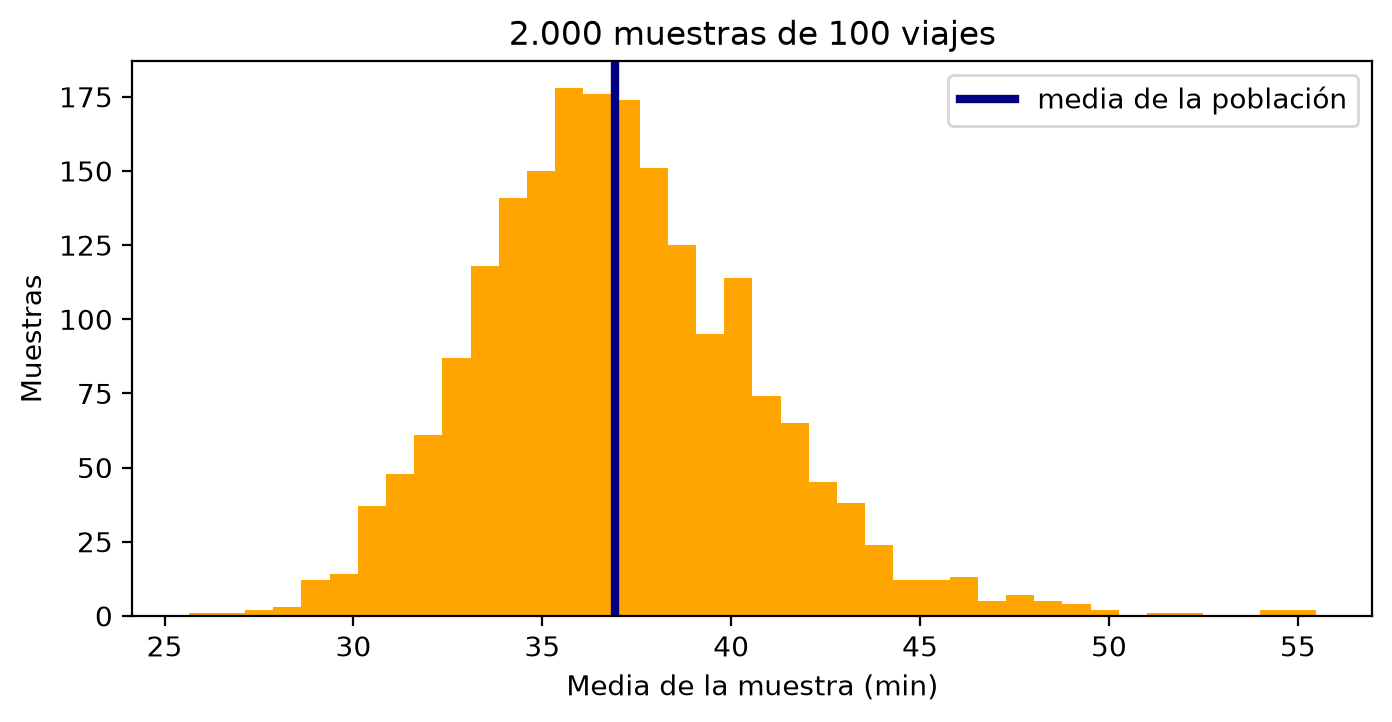

Error estándar (sd de las medias): 3.73
sigma / raíz de n: 3.6


In [9]:
medias = np.array([rng.choice(duracion, 100).mean() for _ in range(2000)])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(medias, bins=40, color="orange")
ax.axvline(duracion.mean(), color="navy", lw=3, label="media de la población")
ax.set(xlabel="Media de la muestra (min)", ylabel="Muestras",
       title="2.000 muestras de 100 viajes")
ax.legend()
plt.show()

print("Error estándar (sd de las medias):", round(medias.std(), 2))
print("sigma / raíz de n:", round(duracion.std() / np.sqrt(100), 2))

Los dos números coinciden, y esa es la fórmula del **error estándar** de la media:

$$EE(\bar{x}) = \frac{\sigma}{\sqrt{n}} \approx \frac{s}{\sqrt{n}}$$

donde $\sigma$ es la desviación estándar de la población (en la práctica se usa $s$, la de la muestra) y $n$ el tamaño de la muestra. Dice cuánto se mueve la media de una muestra a otra, y que para reducirla a la mitad hay que cuadruplicar la muestra.

### El teorema central del límite

**Objetivo:** ver por qué la distribución muestral tiene forma de normal aunque la duración no la tenga.

Repitamos el experimento con muestras de 30, 100 y 500 viajes, y sobre cada histograma dibujemos la normal con media poblacional y desviación $\sigma/\sqrt{n}$:

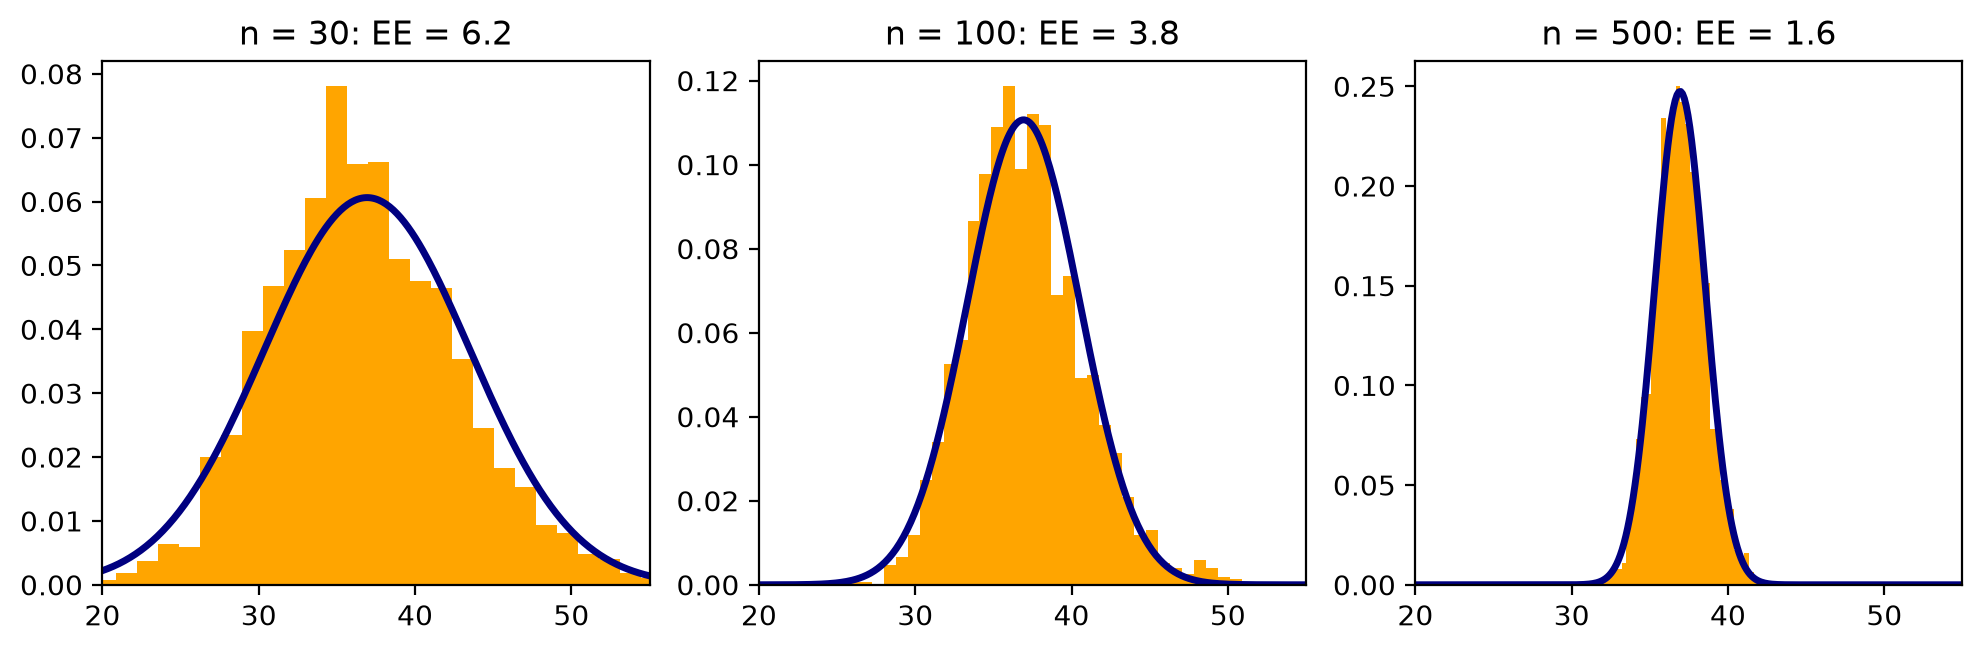

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharex=True)
for ax, n in zip(axes, [30, 100, 500]):
    medias_n = np.array([rng.choice(duracion, n).mean() for _ in range(2000)])
    ax.hist(medias_n, bins=40, density=True, color="orange")
    grilla = np.linspace(20, 55, 300)
    ax.plot(grilla, stats.norm.pdf(grilla, duracion.mean(), duracion.std() / np.sqrt(n)),
            color="navy", lw=2.5)
    ax.set(xlim=(20, 55), title=f"n = {n}: EE = {medias_n.std():.1f}")
plt.show()

Eso es el **teorema central del límite**: la media de una muestra se distribuye aproximadamente normal alrededor de la media de la población, con desviación $\sigma/\sqrt{n}$, **aunque la variable original no sea normal** (la duración tiene una cola larguísima y aun así las medias son una campana). Con $n$ pequeño la aproximación es más gruesa; con $n$ grande es casi perfecta. Por eso la normal es la distribución de la inferencia: no porque los datos sean normales, sino porque los promedios lo son.

## 4. Intervalos de confianza

**Objetivo:** convertir el error estándar en un rango honesto para la media de la población, a partir de una sola muestra.

Si la media muestral cae dentro de $1{,}96$ errores estándar de la poblacional el 95% de las veces (la regla de la normal), entonces el rango

$$\bar{x} \pm 1{,}96 \cdot \frac{s}{\sqrt{n}}$$

atrapa a la media de la población en el 95% de las muestras. Aquí $\bar{x}$ es la media de la muestra, $s/\sqrt{n}$ su error estándar y 1,96 el múltiplo de la normal que deja 95% al centro. Ese rango es el **intervalo de confianza del 95%**. Con una muestra de 100 viajes:

In [11]:
muestra = rng.choice(duracion, 100)
ee = muestra.std(ddof=1) / np.sqrt(100)
inferior, superior = muestra.mean() - 1.96 * ee, muestra.mean() + 1.96 * ee

print(f"media de la muestra: {muestra.mean():.1f} | EE: {ee:.2f}")
print(f"intervalo del 95%: [{inferior:.1f}, {superior:.1f}]")
print(f"media de la población: {duracion.mean():.1f} -> ¿cae dentro? {inferior <= duracion.mean() <= superior}")

media de la muestra: 38.2 | EE: 3.68
intervalo del 95%: [31.0, 45.4]
media de la población: 36.9 -> ¿cae dentro? True


La lectura correcta del 95% es sobre el **procedimiento**, no sobre este intervalo en particular: si repitiéramos el muestreo muchas veces, el 95% de los intervalos atraparía la media real. Como tenemos la población, lo podemos comprobar:

In [12]:
atrapan = 0
for _ in range(1000):
    m = rng.choice(duracion, 100)
    ee = m.std(ddof=1) / 10
    if m.mean() - 1.96 * ee <= duracion.mean() <= m.mean() + 1.96 * ee:
        atrapan += 1
print("Intervalos que atrapan la media real:", atrapan, "de 1000")

Intervalos que atrapan la media real: 925 de 1000


Cerca del 95% (un poco menos: con $n = 100$ y una variable de cola tan larga, la aproximación normal todavía es algo gruesa; con $n$ mayor se acerca al 95% exacto). Dibujemos 100 de esos intervalos:

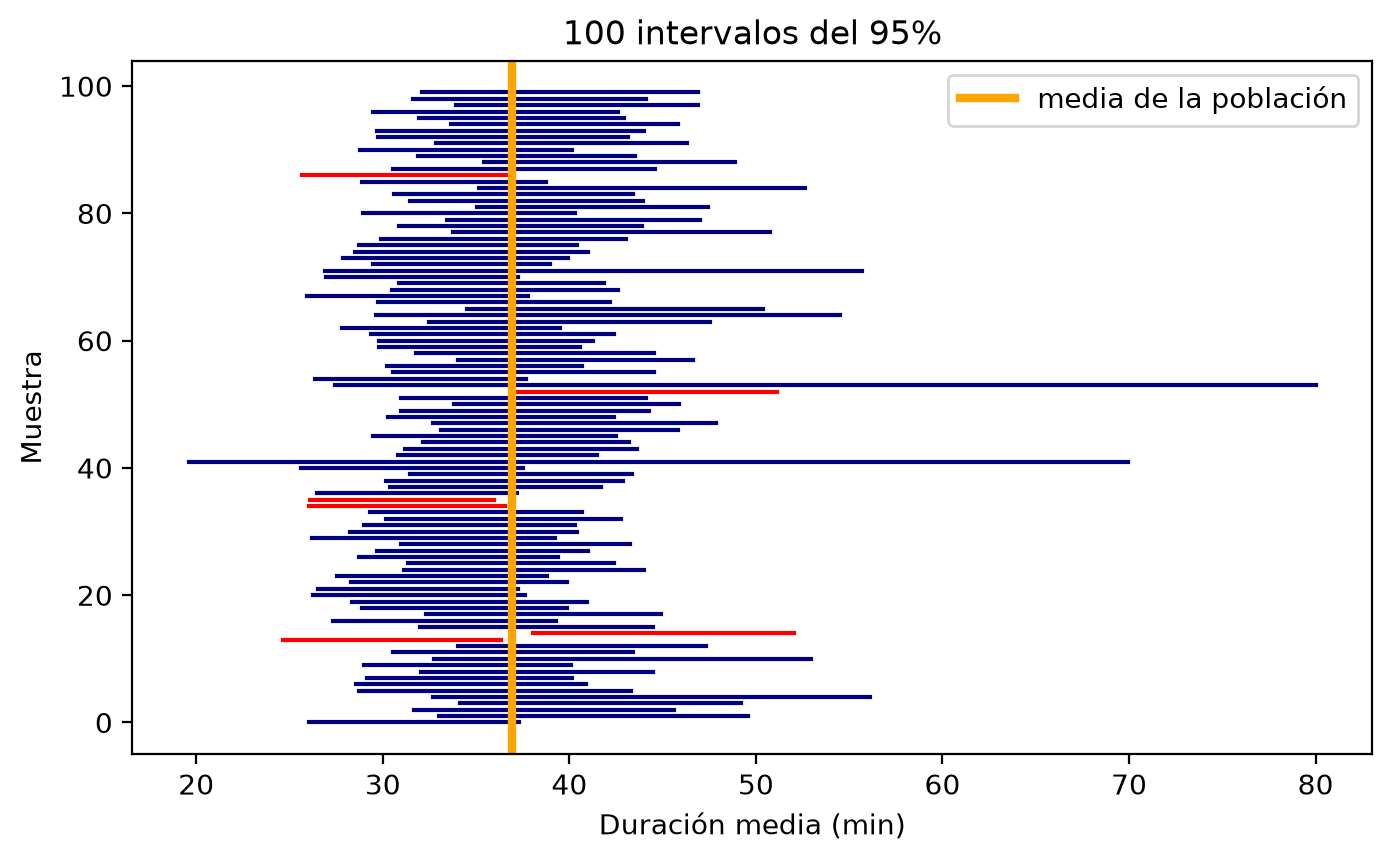

In [13]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for i in range(100):
    m = rng.choice(duracion, 100)
    ee = m.std(ddof=1) / 10
    inferior, superior = m.mean() - 1.96 * ee, m.mean() + 1.96 * ee
    atrapa = inferior <= duracion.mean() <= superior
    ax.plot([inferior, superior], [i, i], color="navy" if atrapa else "red", lw=1.5)
ax.axvline(duracion.mean(), color="orange", lw=3, label="media de la población")
ax.set(xlabel="Duración media (min)", ylabel="Muestra", title="100 intervalos del 95%")
ax.legend()
plt.show()

## 5. Prueba de hipótesis y valor p: la pregunta pendiente

**Objetivo:** responder por fin si la pendiente de −4,8 minutos por millón (duración media de los viajes según el ingreso medio, por comuna) es real o podría ser azar de 45 puntos.

**Qué queremos saber:** si en la ciudad el ingreso de la comuna no tuviera ningún efecto sobre la duración (pendiente real cero), ¿qué tan raro sería obtener una pendiente como la nuestra solo por el azar de qué comunas y qué viajes cayeron en la muestra?

Reconstruimos la tabla por comuna de la clase 3 (ponderada, como entonces):

In [14]:
viajes_final = viajes.merge(hogares[["Hogar", "Comuna", "IngresoHogar"]], on="Hogar")
viajes_final = viajes_final.dropna(subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()
w = viajes_final["FactorLaboralNormal"]
viajes_final["w_ingreso"] = w * viajes_final["IngresoHogar"]
viajes_final["w_duracion"] = w * viajes_final["TiempoViaje"]
suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
por_comuna = pd.DataFrame({
    "ingreso": suma["w_ingreso"] / suma["FactorLaboralNormal"] / 1e6,
    "duracion": suma["w_duracion"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)

45

In [15]:
modelo = sm.OLS(por_comuna["duracion"], sm.add_constant(por_comuna["ingreso"])).fit()
modelo.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
const,38.3352,1.773,21.622,0.000,34.760,41.911
ingreso,-4.8146,2.015,-2.389,0.021,-8.879,-0.750


Ahora podemos leer **toda** la fila del ingreso, columna por columna:

- **coef** = −4,81: la pendiente, minutos menos por cada millón de ingreso medio.
- **std err** = 2,02: el **error estándar de la pendiente**, cuánto se movería con otras 45 comunas. Es el mismo concepto que el error estándar de la media, aplicado al coeficiente.
- **t** = −2,39: el coeficiente dividido por su error estándar. A cuántos errores estándar de distancia está la pendiente del cero.
- **P>|t|** = 0,021: el **valor p**. Si la pendiente real fuera 0, la probabilidad de obtener un t así de lejos (por cualquiera de los dos lados) solo por azar es 2,1%.
- **[0.025, 0.975]** = [−8,9; −0,75]: el intervalo de confianza del 95% de la pendiente. No incluye el 0.

La prueba de hipótesis formal: la **hipótesis nula** $H_0$ es "la pendiente real es 0" (el ingreso no tiene efecto); la **alternativa** $H_1$, que no lo es. El valor p mide qué tan compatible es lo observado con $H_0$. La convención es rechazar $H_0$ cuando $p < 0{,}05$: aquí $p = 0{,}021$, así que la pendiente **no parece azar**. Es la respuesta que debíamos desde la clase 3.

Comprobemos que t y p salen de esa misma cuenta:

In [16]:
b, ee_b = modelo.params["ingreso"], modelo.bse["ingreso"]
t = b / ee_b
# La distribución t con n - 2 grados de libertad; el valor p es el
# área de las dos colas más allá de |t|
gl = len(por_comuna) - 2
p = 2 * (1 - stats.t.cdf(abs(t), gl))

print(f"t = {b:.2f} / {ee_b:.2f} = {t:.2f}")
print(f"valor p = {p:.3f}")
print(f"intervalo 95%: {b - 2.02 * ee_b:.2f} a {b + 2.02 * ee_b:.2f}  (2,02 es el 1,96 de la t con {gl} gl)")

t = -4.81 / 2.02 = -2.39
valor p = 0.021
intervalo 95%: -8.89 a -0.74  (2,02 es el 1,96 de la t con 43 gl)


Con 45 puntos no se usa la normal sino la distribución $t$ de Student, una campana un poco más ancha que corrige por conocer $\sigma$ solo a través de $s$; con $n$ grande son la misma cosa (por eso el 1,96 se vuelve 2,02 aquí).

Y la advertencia de la clase 4 sigue vigente: **significativo no es importante**. La pendiente de la motorización (0,50 vehículos por millón, con 18 mil hogares) tiene $t = 80$ y $p$ prácticamente 0; la de las comunas, con 45 puntos, apenas cruza el umbral. El valor p depende tanto del efecto como del tamaño de la muestra; el tamaño del efecto lo dice el coeficiente, y su precisión, el intervalo.

## 6. Bootstrap: la misma respuesta, sin fórmulas

**Objetivo:** obtener el intervalo de la pendiente remuestreando los datos, y comparar con el de statsmodels.

El **bootstrap** imita el muestreo: toma las 45 comunas, saca 45 **con reemplazo** (algunas se repiten, otras quedan fuera), ajusta la recta, y lo repite miles de veces. La distribución de las pendientes obtenidas es una estimación de cuánto se mueve la pendiente de una muestra a otra, sin suponer normalidad:

In [17]:
x = por_comuna["ingreso"].values
y = por_comuna["duracion"].values
pendientes = []
for _ in range(2000):
    # rng.integers: 45 índices al azar, con repetición
    idx = rng.integers(0, len(x), len(x))
    pendientes.append(np.polyfit(x[idx], y[idx], 1)[0])
pendientes = np.array(pendientes)

inferior, superior = np.percentile(pendientes, [2.5, 97.5])
print(f"intervalo bootstrap 95%: [{inferior:.2f}, {superior:.2f}]")
print(f"fracción de remuestras con pendiente >= 0: {np.mean(pendientes >= 0):.3f}")

intervalo bootstrap 95%: [-9.32, -2.05]
fracción de remuestras con pendiente >= 0: 0.001


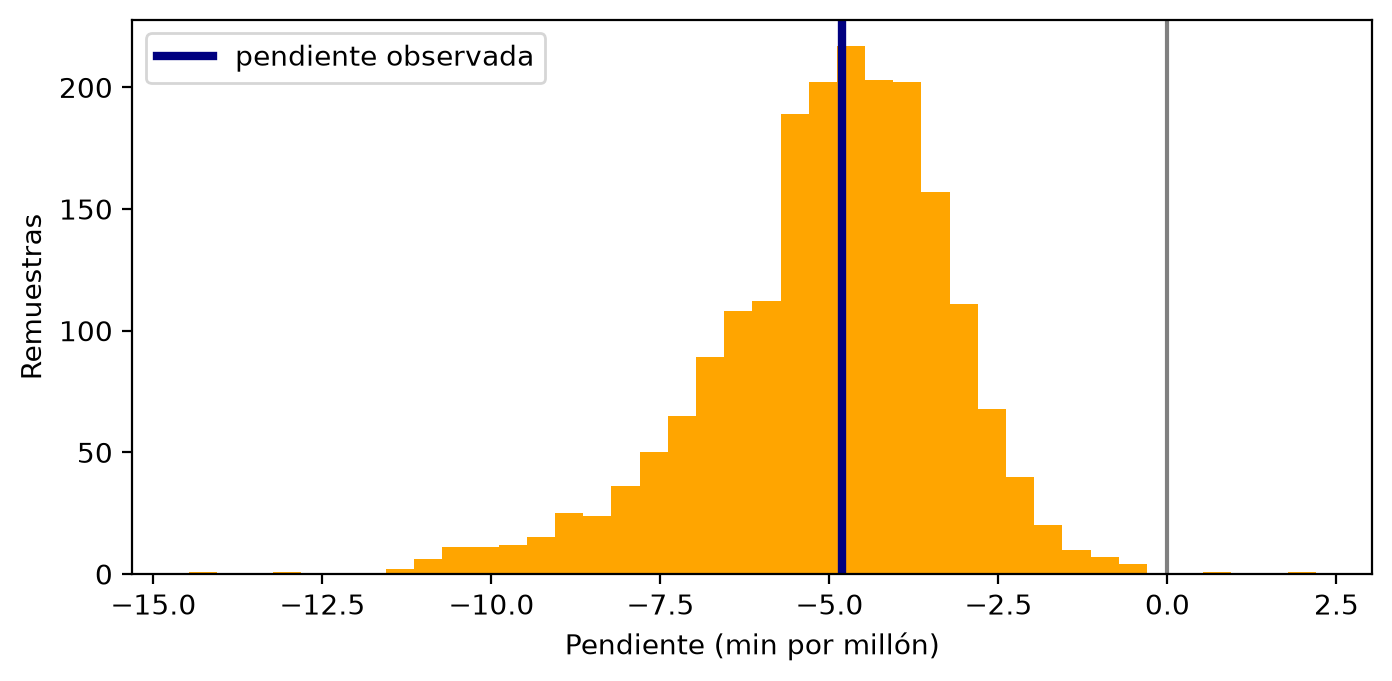

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(pendientes, bins=40, color="orange")
ax.axvline(b, color="navy", lw=3, label="pendiente observada")
ax.axvline(0, color="gray", lw=1.5)
ax.set(xlabel="Pendiente (min por millón)", ylabel="Remuestras")
ax.legend()
plt.show()

El intervalo bootstrap se parece al de statsmodels y casi ninguna remuestra llega al 0: la misma conclusión, por un camino que solo usa el computador. El bootstrap es la herramienta cuando la fórmula no existe o sus supuestos no se cumplen, y sirve para cualquier estadístico (una mediana, una razón, un coeficiente de un modelo complicado).

## 7. La trampa de las comparaciones múltiples

**Objetivo:** ver qué pasa con el valor p cuando se prueban muchas variables a la vez, como en un EDA con una matriz de correlación grande.

Inventemos 20 variables de puro ruido (números normales al azar, sin relación alguna con nada) y probemos cada una contra la duración por comuna:

In [19]:
valores_p = []
for j in range(20):
    ruido = rng.normal(size=len(por_comuna))
    m = sm.OLS(por_comuna["duracion"].values, sm.add_constant(ruido)).fit()
    valores_p.append(m.pvalues[1])
valores_p = np.array(valores_p)

print("valores p:", valores_p.round(3))
print("significativas al 5%:", (valores_p < 0.05).sum(), "de 20")

valores p: [0.988 0.424 0.372 0.408 0.829 0.966 0.622 0.408 0.802 0.037 0.115 0.983
 0.529 0.139 0.791 0.284 0.1   0.609 0.172 0.706]
significativas al 5%: 1 de 20


Con 20 pruebas y un umbral de 0,05, se espera **una** falsa alarma por azar; en más de la mitad de los intentos aparece al menos una "relación significativa" entre la duración y puro ruido. Es exactamente lo que pasa al recorrer una matriz de correlación con 20 variables buscando la que "dé".

Las reglas para el EDA del proyecto: reportar cuántas pruebas se hicieron; desconfiar de un hallazgo aislado entre muchos intentos (la corrección más simple, Bonferroni, divide el umbral por el número de pruebas: 0,05 / 20 = 0,0025); preferir el intervalo de confianza al valor p, porque muestra el tamaño del efecto y su precisión; y recordar siempre que significativo no es importante.

## 8. Ejercicio 

Con los datos de su proyecto (o con la EOD si aún no los tiene):

1. Calcule el error estándar y el intervalo de confianza del 95% de la media de su variable objetivo.
2. Ajuste una regresión simple con statsmodels y lea la fila completa de su variable: coeficiente, error estándar, t, valor p e intervalo. ¿Qué concluye?
3. Obtenga el intervalo de la pendiente por bootstrap y compárelo con el de statsmodels.
4. Cuente cuántas correlaciones probó en su EDA y aplique la regla de las comparaciones múltiples.

Todo esto es material directo para el primer análisis exploratorio, que se entrega el lunes 15.

In [20]:
# Su solución


---

**Próxima clase (jueves 10-sep):** regresión lineal en profundidad: supuestos, diagnósticos con los residuos y cómo evaluar un modelo fuera de la muestra. Recuerde: el primer análisis exploratorio se entrega el lunes 15 de septiembre.